Running FFT for a random image. Need to subtract the average height because otherwise we will just get a black image on the output since the average (0 frequency, or the DC component) will dominate this. Apparently, this is common in AFM.

For quantum dots FFT is mostly usedful for: 
1. Detecting periodicity/ order 
2. Detecting scan artefacts
3. separating length scales 
4. estimating characteristic dot spacing -> HOW 
5. Designing filters 

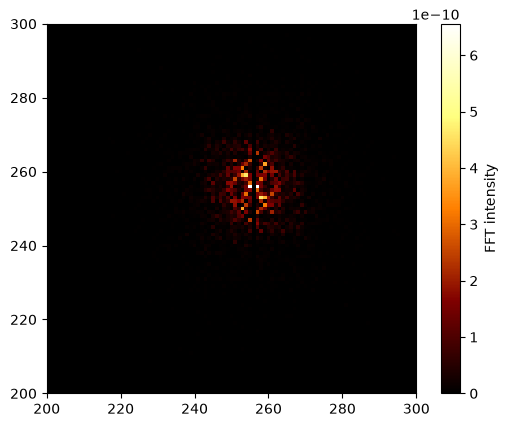

In [2]:
import numpy as np
import matplotlib.pyplot as plt

z = np.load("data_numpy/2nm_QD_AFMs_AIX6461_along_the_flat_edge_1um_200pN_15gain_2um_zrange.0_00000/channel_00___0_data.npy")
z_nobackground = z - np.mean(z)
F = np.fft.fftshift(np.fft.fft2(z_nobackground))

power = np.abs(F)**2

plt.imshow(np.log(power + 1), cmap="afmhot")
plt.colorbar(label="FFT intensity")

plt.xlim(200, 300)
plt.ylim(200, 300)

plt.show()

However, the range is very high. So, lets take the magnitude and plot it on the log scale: 

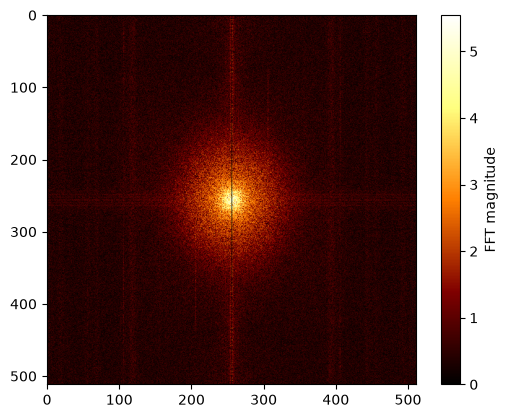

In [3]:
magnitude = np.abs(F)*10e6

plt.imshow(
    np.log1p(magnitude),
    cmap="afmhot"
)

plt.colorbar(label="FFT magnitude")
plt.show()

Using Gaussian filtering, remove the low-frequency background

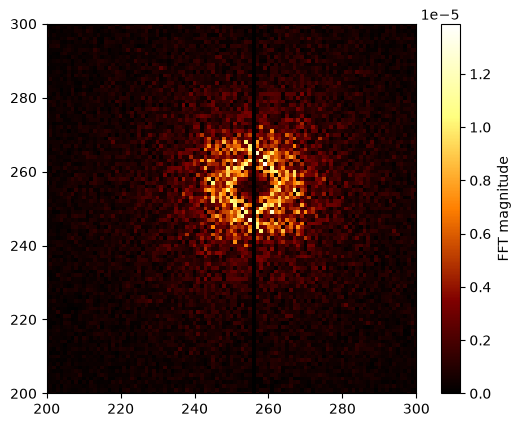

In [4]:
from scipy.ndimage import gaussian_filter

background = gaussian_filter(z, sigma=20)

z_filtered = z - background

F = np.fft.fftshift(np.fft.fft2(z_filtered))

plt.imshow(
    np.log1p(np.abs(F)),
    cmap="afmhot"
)

plt.colorbar(label="FFT magnitude")

plt.xlim(200, 300)
plt.ylim(200, 300)

plt.show()

FFT band-pass filter function testing

In [5]:
from __future__ import annotations

import numpy as np
from scipy.ndimage import gaussian_filter


def fft_bandpass(
    image: np.ndarray,
    low_sigma: float = 1,
    high_sigma: float = 10,
) -> np.ndarray:
    """
    Band-pass filter an AFM image using Fourier space.

    Keeps intermediate spatial frequencies:
    - removes slow background variations
    - removes high-frequency noise

    Parameters
    ----------
    image:
        2D AFM height array

    low_sigma:
        Controls removal of high-frequency noise.
        Smaller = keep finer details.

    high_sigma:
        Controls removal of background.
        Larger = remove larger structures.

    Returns
    -------
    filtered_image:
        Band-pass filtered AFM image
    """

    image = np.asarray(image, dtype=float)

    # remove mean height
    image = image - np.mean(image)

    # FFT
    F = np.fft.fftshift(np.fft.fft2(image))

    ny, nx = image.shape

    y, x = np.indices(image.shape)

    cx = nx // 2
    cy = ny // 2

    r = np.sqrt(
        (x - cx)**2 +
        (y - cy)**2
    )

    # Fourier Gaussian masks
    low_pass = np.exp(
        -(r**2)/(2*high_sigma**2)
    )

    high_pass = 1 - np.exp(
        -(r**2)/(2*low_sigma**2)
    )

    bandpass_mask = low_pass * high_pass

    # apply filter
    F_filtered = F * bandpass_mask

    # inverse FFT
    filtered = np.real(
        np.fft.ifft2(
            np.fft.ifftshift(F_filtered)
        )
    )

    return filtered

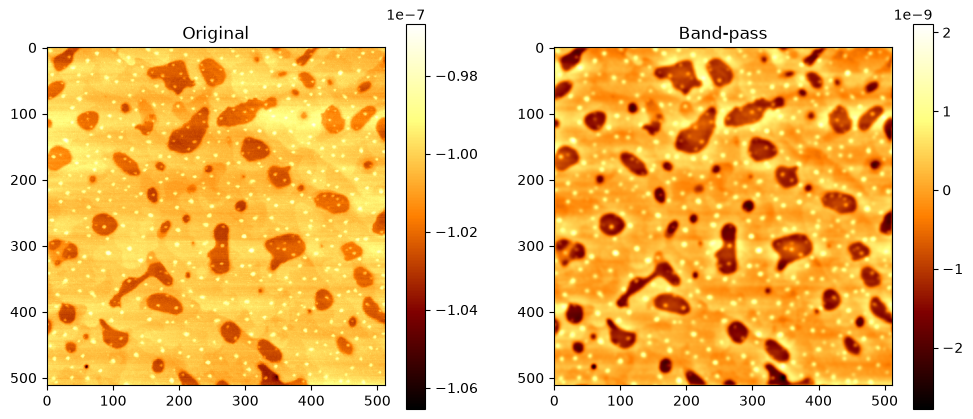

In [6]:
z_filtered = fft_bandpass(
    z,
    low_sigma=5,
    high_sigma=40
)


plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(z, cmap="afmhot")
plt.title("Original")
plt.colorbar()


plt.subplot(1,2,2)
plt.imshow(z_filtered, cmap="afmhot")
plt.title("Band-pass")
plt.colorbar()


plt.show()

Quantum dots appear as halo effect on the FFT, so we can quantify them using FFT or at least try finding their characteristics

The distance from the center corresponds to the inverse of your spatial distances 1/lambda. The angle of the spots indicates the alignment direction of the dots (e.g., self-assembled linear chains along specific crystallographic step edges) 
https://www.sciencedirect.com/science/article/pii/S0169433223001940?__cf_chl_f_tk=YJBFMlXXGtf3M5XObAKVd4wQ49Iv38h0nNXggozaJw0-1783435783-1.0.1.1-FPUAAJPymiutSDDc3XulPfOcpp64fsEhst8XZy4TOx8 

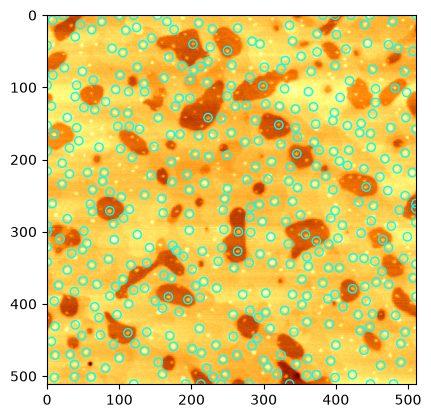

In [12]:
from skimage.feature import blob_log
from sklearn.preprocessing import StandardScaler

from skimage.filters import gaussian, sobel, threshold_otsu
from skimage.morphology import remove_small_objects
import matplotlib.pyplot as plt

z_norm = (
    z_filtered - np.mean(z_filtered)
) / np.std(z_filtered)

z_norm = gaussian(z_norm, sigma=1)

blobs = blob_log(
    z_norm,
    min_sigma=1, # values are in pixels, so works just like imagej
    max_sigma=8,
    num_sigma=20,
    threshold=0.5
)

plt.imshow(z, cmap="afmhot")

plt.scatter(
    blobs[:,1],
    blobs[:,0],
    facecolors="none",
    edgecolors="cyan"
)

plt.show()

In [13]:
print(len(blobs))

393


Applying an edge filter to ensure nothing is outside the edges of the QD and so that we see what python thinks is a dot


1. Sobel = default, estimates gradients with weighting the middle row/ colun more strongly so Sobel does some smoothing while finding edges. Used when you want a stable general-purpose edge map 

2. Scharr = sharper and more rotationally symmetric than Sobel but ofter better when you care about edge direction not being biased by pixel-grid orientation. Use when sobel looks slightly uneven or directional 

3. Prewitt = does less smoothing than Sobel, so can be more sensitive to noise 

4. Roberts = reacts to very local diagonal changes. Used when you want very fine local edges.

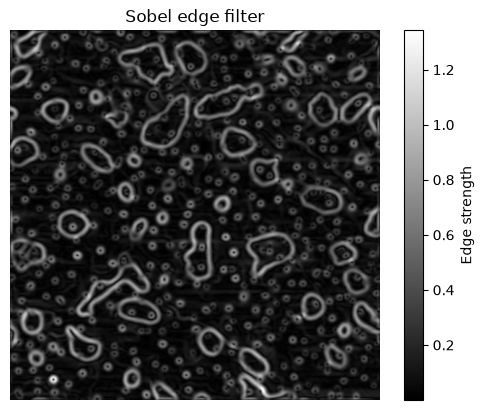

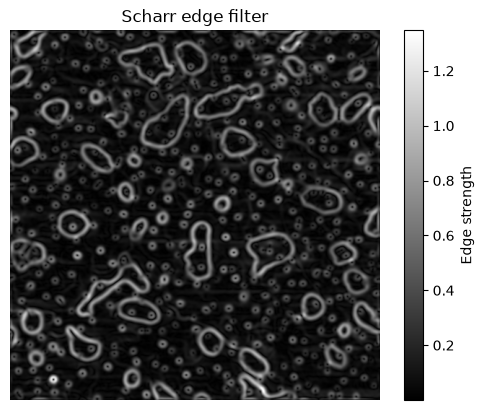

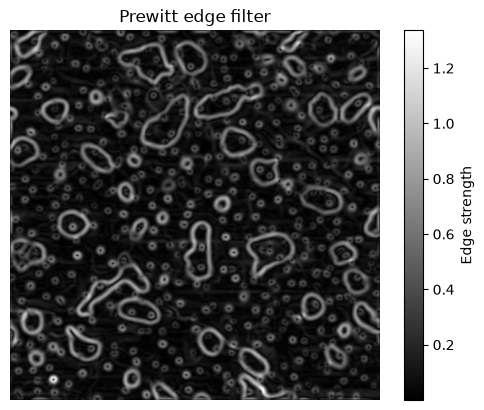

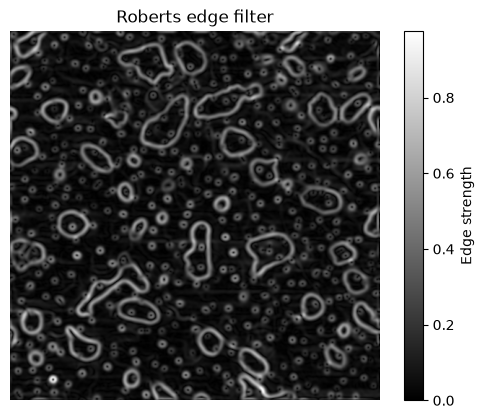

In [14]:
import matplotlib.pyplot as plt
from skimage import filters

sobel_edges = filters.sobel(z_norm)
scharr_edges = filters.scharr(z_norm)
prewitt_edges = filters.prewitt(z_norm)
roberts_edges = filters.roberts(z_norm)

plt.imshow(sobel_edges, cmap="gray")
plt.colorbar(label="Edge strength")
plt.title("Sobel edge filter")
plt.axis("off")
plt.show()

plt.imshow(scharr_edges, cmap="gray")
plt.colorbar(label="Edge strength")
plt.title("Scharr edge filter")
plt.axis("off")
plt.show()

plt.imshow(prewitt_edges, cmap="gray")
plt.colorbar(label="Edge strength")
plt.title("Prewitt edge filter")
plt.axis("off")
plt.show()

plt.imshow(roberts_edges, cmap="gray")
plt.colorbar(label="Edge strength")
plt.title("Roberts edge filter")
plt.axis("off")
plt.show()

/var/folders/mh/m6vpz3p153zc20j8vy1vf3780000gn/T/ipykernel_84576/3704080031.py:16: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  edge_mask_clean_sobel = remove_small_objects(edge_mask_sobel, min_size=8)
/var/folders/mh/m6vpz3p153zc20j8vy1vf3780000gn/T/ipykernel_84576/3704080031.py:17: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only remove

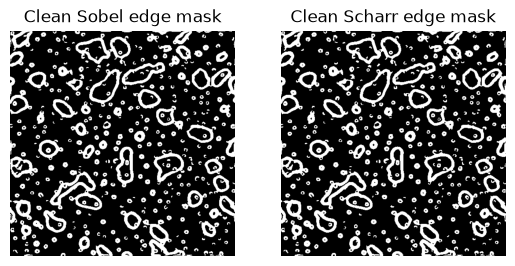

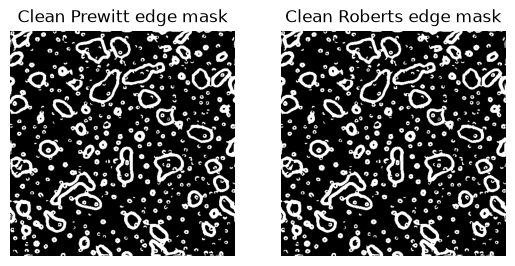

In [27]:
# 3. Threshold
threshold = threshold_otsu(sobel_edges)
edge_mask_sobel = sobel_edges > threshold

threshold = threshold_otsu(scharr_edges)
edge_mask_scharr = scharr_edges < threshold

threshold = threshold_otsu(prewitt_edges)
edge_mask_prewitt = prewitt_edges < threshold

threshold = threshold_otsu(roberts_edges)
edge_mask_roberts = roberts_edges < threshold

# 4. Clean tiny noise objects

edge_mask_clean_sobel = remove_small_objects(edge_mask_sobel, min_size=8)
edge_mask_clean_scharr = remove_small_objects(edge_mask_sobel, min_size=8)
edge_mask_clean_prewitt = remove_small_objects(edge_mask_sobel, min_size=8)
edge_mask_clean_roberts = remove_small_objects(edge_mask_sobel, min_size=8)

fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.imshow(edge_mask_clean_sobel, cmap="gray")
ax1.set_title("Clean Sobel edge mask")
ax1.axis('off')

ax2.imshow(edge_mask_clean_scharr, cmap="gray")
ax2.set_title("Clean Scharr edge mask")
ax2.axis('off')

fig, (ax3, ax4) = plt.subplots(1, 2)

ax3.imshow(edge_mask_clean_prewitt, cmap="gray")
ax3.set_title("Clean Prewitt edge mask")
ax3.axis("off")

ax4.imshow(edge_mask_clean_roberts, cmap="gray")
ax4.set_title("Clean Roberts edge mask")
ax4.axis("off")


plt.show()

These all looked the same, so felt like subtracting them:

/var/folders/mh/m6vpz3p153zc20j8vy1vf3780000gn/T/ipykernel_84576/3193309245.py:28: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = remove_small_objects(mask, min_size=20)


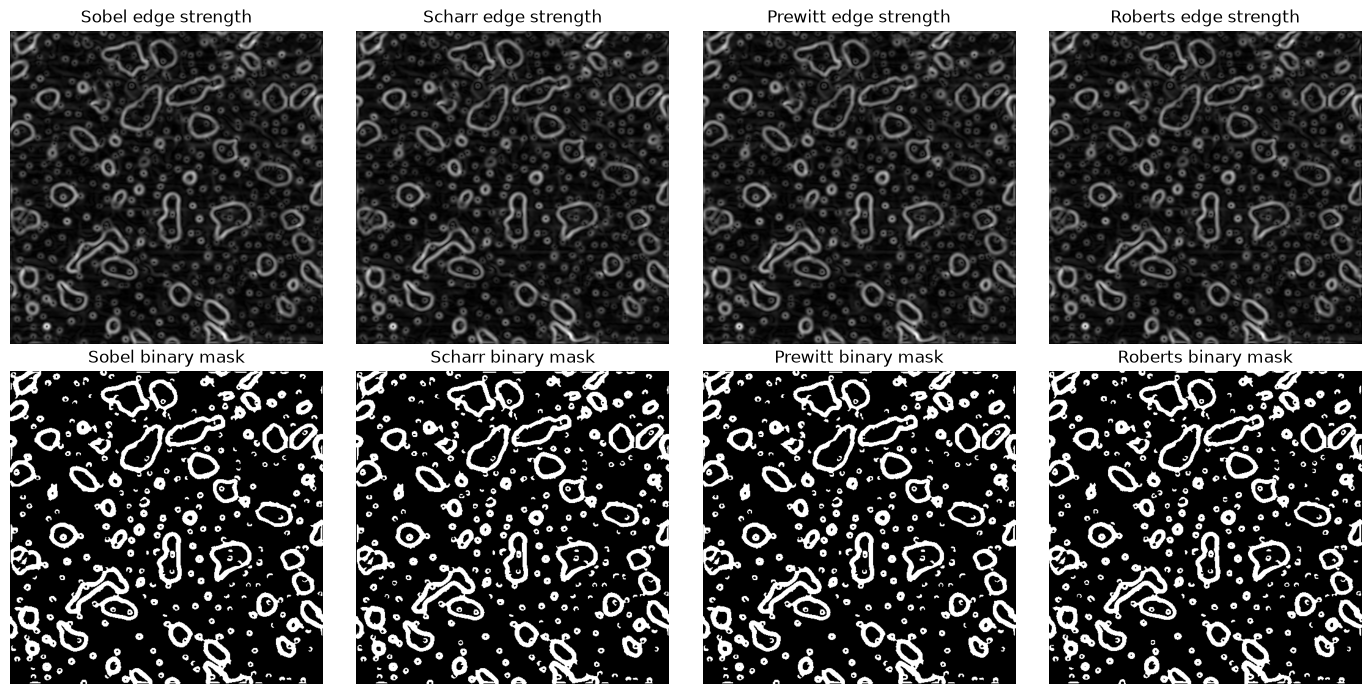

In [28]:
from skimage.filters import gaussian, sobel, scharr, prewitt, roberts
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects
import matplotlib.pyplot as plt

# topo = your AFM/topography array

topo_smooth = gaussian(z_norm, sigma=1, preserve_range=True)

edge_maps = {
    "Sobel": sobel(topo_smooth),
    "Scharr": scharr(topo_smooth),
    "Prewitt": prewitt(topo_smooth),
    "Roberts": roberts(topo_smooth),
}

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for i, (name, edges) in enumerate(edge_maps.items()):
    # continuous edge strength
    axes[0, i].imshow(edges, cmap="gray")
    axes[0, i].set_title(f"{name} edge strength")
    axes[0, i].axis("off")

    # binary mask
    threshold = threshold_otsu(edges)
    mask = edges > threshold
    mask = remove_small_objects(mask, min_size=20)

    axes[1, i].imshow(mask, cmap="gray")
    axes[1, i].set_title(f"{name} binary mask")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

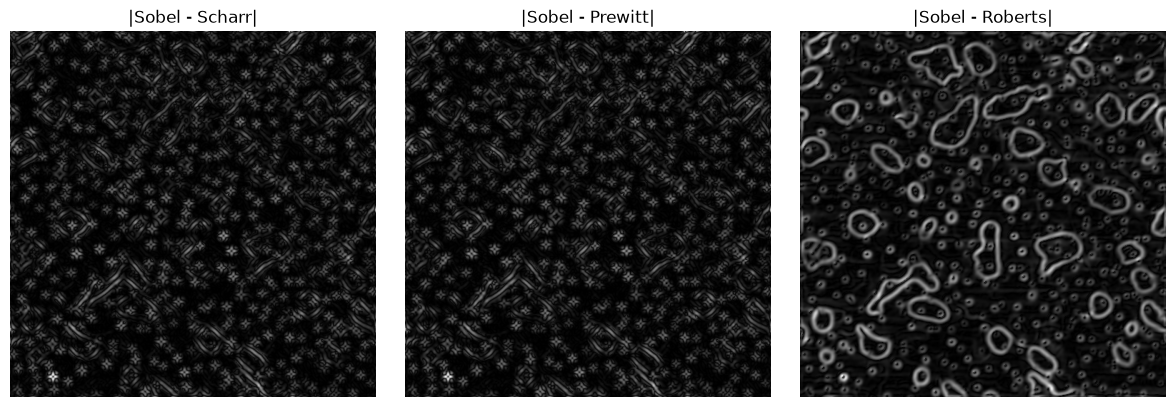

In [29]:
sobel_edges = edge_maps["Sobel"]
scharr_edges = edge_maps["Scharr"]
prewitt_edges = edge_maps["Prewitt"]
roberts_edges = edge_maps["Roberts"]

diff_sobel_scharr = abs(sobel_edges - scharr_edges)
diff_sobel_prewitt = abs(sobel_edges - prewitt_edges)
diff_sobel_roberts = abs(sobel_edges - roberts_edges)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(diff_sobel_scharr, cmap="gray")
axes[0].set_title("|Sobel - Scharr|")
axes[0].axis("off")

axes[1].imshow(diff_sobel_prewitt, cmap="gray")
axes[1].set_title("|Sobel - Prewitt|")
axes[1].axis("off")

axes[2].imshow(diff_sobel_roberts, cmap="gray")
axes[2].set_title("|Sobel - Roberts|")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [30]:
import numpy as np

for name, edges in edge_maps.items():
    diff = np.mean(np.abs(sobel_edges - edges))
    print(f"Mean absolute difference Sobel vs {name}: {diff:.6f}")

Mean absolute difference Sobel vs Sobel: 0.000000
Mean absolute difference Sobel vs Scharr: 0.000533
Mean absolute difference Sobel vs Prewitt: 0.000710
Mean absolute difference Sobel vs Roberts: 0.053573
